# Revisions analyses

## 1.1 Setting a DNA count threshold to investigate integration site effects

In [1]:
import polars as pl
import seaborn as sns
import os
import matplotlib.pyplot as plt

In [2]:
cd = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/"
minDNAcount3 = pl.read_csv(os.path.join(cd, "results/MPRA_analysis/CMPRA5/labeled_data_minDNAcount3_OA.tsv"), separator="\t")
minDNAcount5 = pl.read_csv(os.path.join(cd, "results/MPRA_analysis/CMPRA5/labeled_data_minDNAcount5_OA.tsv"), separator="\t")
minDNAcount10 = pl.read_csv(os.path.join(cd, "results/MPRA_analysis/CMPRA5/labeled_data_minDNAcount10_OA.tsv"), separator="\t")

original = pl.read_csv(os.path.join(cd, "results/MPRA_analysis/CMPRA5/labeled_data_promoteroa_OA.tsv"), separator="\t")

In [17]:
joint_original_minDNAcounts3 = minDNAcount3.join(
	original.select("left_bin", "right_bin", "adj.P.Val", "logFC", "z_score", "promoter_only", "std", "effect"), 
	on=["left_bin", "right_bin"], suffix="_original")

joint_original_minDNAcounts5 = minDNAcount5.join(
	original.select("left_bin", "right_bin", "adj.P.Val", "logFC", "z_score", "promoter_only", "std", "effect"), 
	on=["left_bin", "right_bin"], suffix="_original")

joint_original_minDNAcounts10 = minDNAcount10.join(
	original.select("left_bin", "right_bin", "adj.P.Val", "logFC", "z_score", "promoter_only", "std", "effect"), 
	on=["left_bin", "right_bin"], suffix="_original")	

Text(0.5, 1.0, 'logFC comparison original vs minDNAcount3')

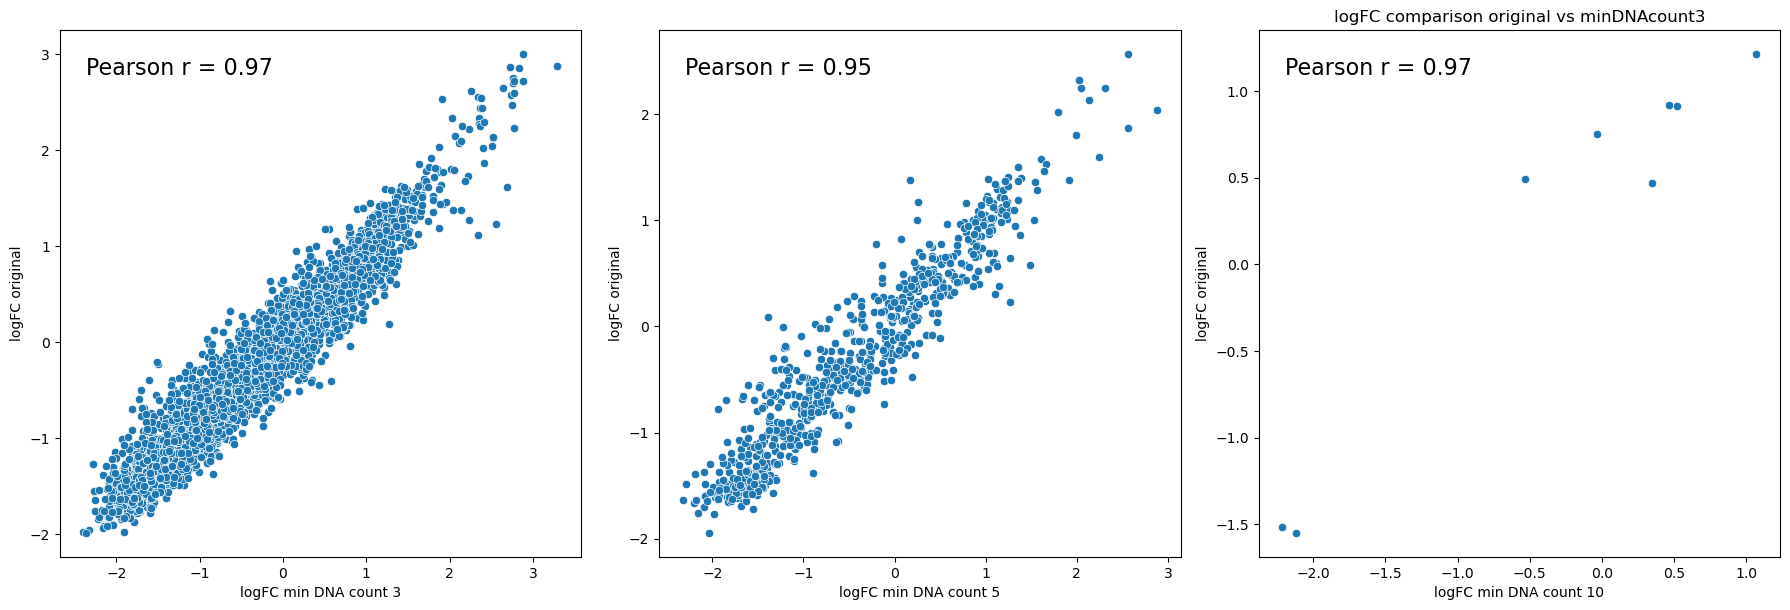

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.scatterplot(
	data=joint_original_minDNAcounts3.to_pandas(),
	x="logFC",
	y="logFC_original",
	ax=axes[0]
)
axes[0].set_xlabel("logFC min DNA count 3")
axes[0].set_ylabel("logFC original")

sns.scatterplot(
	data=joint_original_minDNAcounts5.to_pandas(),
	x="logFC",
	y="logFC_original",
	ax=axes[1]
)
axes[1].set_xlabel("logFC min DNA count 5")
axes[1].set_ylabel("logFC original")

sns.scatterplot(
	data=joint_original_minDNAcounts10.to_pandas(),
	x="logFC",
	y="logFC_original",
	ax=axes[2]
)
axes[2].set_xlabel("logFC min DNA count 10")
axes[2].set_ylabel("logFC original")
corrs = [
	joint_original_minDNAcounts3.select(pl.corr("logFC", "logFC_original")).item(),
	joint_original_minDNAcounts5.select(pl.corr("logFC", "logFC_original")).item(),
	joint_original_minDNAcounts10.select(pl.corr("logFC", "logFC_original")).item()
]

for i, ax in enumerate(axes):
	ax.text(
		0.05, 0.95,
		f"Pearson r = {corrs[i]:.2f}",
		transform=ax.transAxes,
		fontsize=16,
		verticalalignment='top',
		#bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
	)
plt.tight_layout()
plt.title("logFC comparison original vs minDNAcount3")

In [20]:
joint_original_minDNAcounts3.select(pl.corr("logFC", "logFC_original"), pl.corr("z_score", "z_score_original")), \
joint_original_minDNAcounts5.select(pl.corr("logFC", "logFC_original"), pl.corr("z_score", "z_score_original")), \
joint_original_minDNAcounts10.select(pl.corr("logFC", "logFC_original"), pl.corr("z_score", "z_score_original"))

(shape: (1, 2)
 ┌──────────┬──────────┐
 │ logFC    ┆ z_score  │
 │ ---      ┆ ---      │
 │ f64      ┆ f64      │
 ╞══════════╪══════════╡
 │ 0.968742 ┆ 0.714213 │
 └──────────┴──────────┘,
 shape: (1, 2)
 ┌──────────┬──────────┐
 │ logFC    ┆ z_score  │
 │ ---      ┆ ---      │
 │ f64      ┆ f64      │
 ╞══════════╪══════════╡
 │ 0.948822 ┆ 0.491722 │
 └──────────┴──────────┘,
 shape: (1, 2)
 ┌─────────┬─────────┐
 │ logFC   ┆ z_score │
 │ ---     ┆ ---     │
 │ f64     ┆ f64     │
 ╞═════════╪═════════╡
 │ 0.97058 ┆ NaN     │
 └─────────┴─────────┘)

In [51]:
# Calculate Jaccard index between 'effect' and 'effect_original'

def rowwise_jaccard_index(df):
	effect = df["effect"].to_list()
	effect_original = df["effect_original"].to_list()
	matches = sum(e == o for e, o in zip(effect, effect_original) if e is not None and e != 'no effect')
	non_matches = sum(e != o for e, o in zip(effect, effect_original) if e is not None and o is not None)
	total = matches + non_matches
	print(matches, non_matches)
	return matches / total if total > 0 else float('nan')


jaccard_index_rowwise_3 = rowwise_jaccard_index(joint_original_minDNAcounts3)
print("Row-wise Jaccard index (minDNAcount3):", jaccard_index_rowwise_3)

jaccard_index_rowwise_5 = rowwise_jaccard_index(joint_original_minDNAcounts5)
print("Row-wise Jaccard index (minDNAcount5):", jaccard_index_rowwise_5)

jaccard_index_rowwise_10 = rowwise_jaccard_index(joint_original_minDNAcounts10)
print("Row-wise Jaccard index (minDNAcount10):", jaccard_index_rowwise_10)

11 45
Row-wise Jaccard index (minDNAcount3): 0.19642857142857142
0 3
Row-wise Jaccard index (minDNAcount5): 0.0
0 0
Row-wise Jaccard index (minDNAcount10): nan


In [30]:
print("Unique values per dataframe:")
print(f"joint_original_minDNAcounts3: {joint_original_minDNAcounts3.n_unique()}")
print(f"joint_original_minDNAcounts5: {joint_original_minDNAcounts5.n_unique()}")
print(f"joint_original_minDNAcounts10: {joint_original_minDNAcounts10.n_unique()}")
print(f"original: {original.n_unique()}")

Unique values per dataframe:
joint_original_minDNAcounts3: 4358
joint_original_minDNAcounts5: 741
joint_original_minDNAcounts10: 8
original: 83501


## 2.2/2.3 Multiple BCs per sequence vs multiple sequences per bin

In [3]:
mpra = original.filter(pl.col("z_score").is_not_null())

In [51]:
many_bcs = mpra.filter((pl.col("nr_seqs") == 1) & (pl.col("nr_reads") > 20))
many_seqs = mpra.filter((pl.col("nr_seqs") > 10) & (pl.col("nr_seqs") < 50))

print(f"Number of barcodes with >20 barcodes and just 1 sequence: {many_bcs.height}")
print(f"Number of sequences with >10 sequences: {many_seqs.height}")

Number of barcodes with >20 barcodes and just 1 sequence: 691
Number of sequences with >10 sequences: 606


In [52]:
many_bcs.select("logFC", "z_score", "adj.P.Val").mean()

logFC,z_score,adj.P.Val
f64,f64,f64
0.137918,0.216859,0.0582


In [53]:
many_seqs.select("logFC", "z_score", "adj.P.Val").mean()

logFC,z_score,adj.P.Val
f64,f64,f64
-0.012928,-0.110401,0.081505


(-0.5, 50.0)

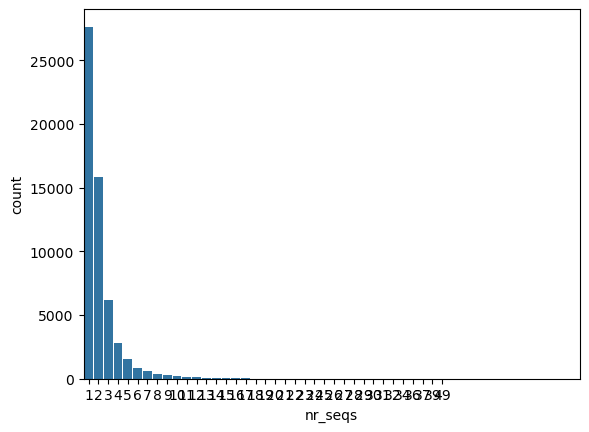

In [54]:
sns.barplot(
	mpra.select(pl.col("nr_seqs"), pl.len().over("nr_seqs").alias("count")).unique().sort("nr_seqs").to_pandas(),
	x="nr_seqs",
	y="count", width=0.9
)
plt.xlim(-0.5, 50)

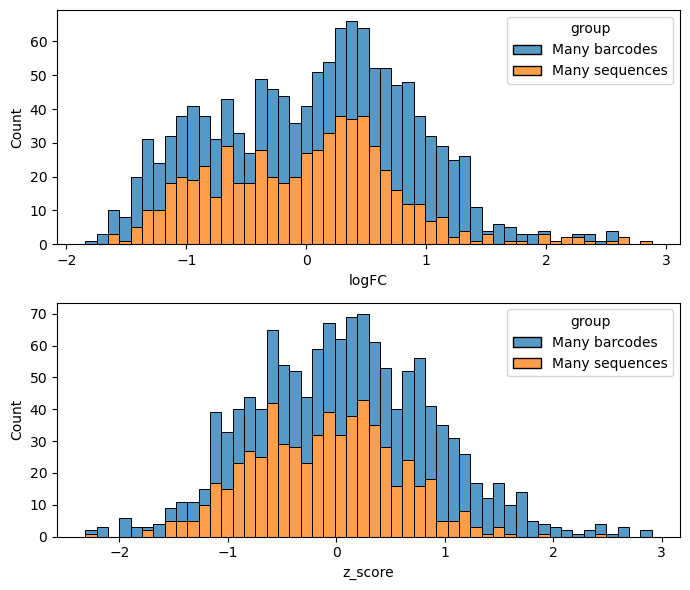

In [74]:
fig, axs = plt.subplots(2,1,figsize=(7, 6))

both = pl.concat([many_bcs, many_seqs]).with_columns(
	pl.when(pl.col("nr_seqs") == 1).then(pl.lit("Many barcodes")).otherwise(pl.lit("Many sequences")).alias("group")
)
sns.histplot(both.to_pandas(), x="logFC", bins=50, hue="group", multiple="stack", ax=axs[0])
sns.histplot(both.to_pandas(), x="z_score", bins=50, hue="group", multiple="stack", ax=axs[1])
plt.tight_layout()

### Looking at differences in sequence lengths and coordinates

In [ ]:

mpra.select("left_bin", "right_bin").write_csv(os.path.join(tempdir, "bins.tsv"), separator="\t", include_header=False)

In [4]:
tempdir = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/"
os.makedirs(tempdir, exist_ok=True)
bins = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins.tsv"
seqids = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/temp.seqids.tsv"

In [119]:
!zcat '/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/results/mprasnakeflow/results/assigned_bcs_part1and2.tsv.gz' | cut -f -2,4,6,8,10,12,14 | awk 'NR > 1 && NF >=5' | cut -f 2 | sed 's/>//' > $seqids

In [ ]:
!awk -v FS="\t" '{print $1"-"$2"-"$3"-"$4"S"$5"-"$6"-"$7"-"$8"\t"$9}' \
	<(zcat '/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/mpra_capture_flow/results/CMPRA5/binned/prommoteroa_bins_all.filt_OA.bed.gz') \
		| grep -Fwf <(sed 's/\t/S/' $bins) | sed 's/S/\t/' > "$tempdir""bins_with_seqs.tsv"

In [163]:
!awk -v FS="\t" '{print $1"-"$2"-"$3"-"$4"S"$5"-"$6"-"$7"-"$8"\t"$9}' \
	<(zcat '/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/mpra_capture_flow/results/CMPRA5/binned/prommoteroa_bins_all.filt_OA.bed.gz') \
	| grep -Fwf <(sed 's/\t/S/' "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins.tsv") | sed 's/S/\t/' > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_with_seqs.tsv"

In [171]:
!awk '{split($3,seqs,","); for (i in seqs) print $1"\t"$2"\t"seqs[i]}' "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_with_seqs.tsv" | sort | uniq -c | awk '{print $2"\t"$3"\t"$4"\t"$5"\t"$1}' | grep -Fwf "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/temp.seqids.tsv" > "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_with_used_seqs.tsv"

In [10]:
!samtools view -N  <(cut -f 3 "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_with_used_seqs.tsv") "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/mpra_capture_flow/results/CMPRA5/merged_samples.tagged.bam" > \
	"/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/mapped.sam"

In [16]:
!awk -v OFS="\t" '{if ($2 == 0) print $3,$4,$4 + length($10), $1; else print $3,$4 - length($10),$4, $1}'  "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/mapped.sam" \
	> "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/seqcoordinates.bed"

In [15]:
!head "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_with_used_seqs.tsv" 

chr1-101801233-101801506-.	chr1-103617113-103617668-+	m84066_240623_122801_s1/13893758/ccs		1
chr1-10211506-10211693-.	chr1-11805849-11806206-+	m84066_240623_102831_s3/56824659/ccs		1
chr1-102125870-102126043-.	chr1-103616844-103617112-+	m84066_240516_024507_s2/196281282/ccs		1
chr1-102601762-102602003-.	chr1-103616844-103617112-+	m84066_240516_024507_s2/10290717/ccs		1
chr1-103136691-103136979-.	chr1-103616844-103617112-+	m84066_240623_102831_s3/163971436/ccs		1
chr1-103380338-103380418-.	chr1-103616844-103617112-+	m84066_240623_102831_s3/100536900/ccs		1
chr1-103380338-103380418-.	chr1-103617113-103617668-+	m84066_240623_102831_s3/100536900/ccs		1
chr1-103465497-103465619-.	chr1-103616844-103617112-+	m84066_240623_122801_s1/131011202/ccs		1
chr1-103569914-103570122-.	chr1-103617113-103617668-+	V350161981_L03_contig_1007684		1
chr1-103596224-103596429-.	chr1-103616844-103617112-+	m84066_240623_102831_s3/251987327/ccs		1


In [33]:
!sort -k4,4 -k2,2 -k3,3 "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/seqcoordinates.bed" | \
	awk -v OFS="\t" '{if ($4 == prev) print $1,prev_start,prev_end,$2,$3,$4; prev=$4; prev_start=$2; prev_end=$3}' \
		> "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/double_seqcoordinates.tsv"

In [36]:
!wc -l "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/double_seqcoordinates.tsv" \
	"/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/seqcoordinates.bed"

   91652 /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/double_seqcoordinates.tsv
  183304 /data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/seqcoordinates.bed
  274956 total


In [37]:
!head "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/double_seqcoordinates.tsv"

chr2	99174344	99174657	99180384	99180852	V350161981_L02_contig_100096
chr20	5119696	5120285	5123081	5123279	V350161981_L02_contig_1002303
chr6	151450568	151451484	151452275	151452398	V350161981_L02_contig_1002493
chr12	111598902	111599592	111606115	111606178	V350161981_L02_contig_1002605
chr20	35456447	35456537	35741797	35742183	V350161981_L02_contig_1002901
chr13	45464674	45465113	45481041	45481352	V350161981_L02_contig_1006285
chr2	130835499	130835545	130835945	130836690	V350161981_L02_contig_100659
chr1	45521517	45521924	45537568	45537741	V350161981_L02_contig_1006693
chr6	11231727	11232214	11419894	11420071	V350161981_L02_contig_1007053
chr2	170715320	170715617	170716703	170717077	V350161981_L02_contig_1008084


In [39]:
bins = pl.read_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/bins_with_used_seqs.tsv", 
	separator="\t", columns=[0,1,2],has_header=False, new_columns=["left_bin", "right_bin", "seq_id"])
coords = pl.read_csv("/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/tmp/double_seqcoordinates.tsv", 
	separator="\t",has_header=False, new_columns=["chrom", "start_left", "end_left", "start_right", "end_right", "seq_id"])

In [40]:
bins.join(coords, on="seq_id").head()

left_bin,right_bin,seq_id,chrom,start_left,end_left,start_right,end_right
str,str,str,str,i64,i64,i64,i64
"""chr1-101801233-101801506-.""","""chr1-103617113-103617668-+""","""m84066_240623_122801_s1/138937…","""chr1""",101800960,101801236,103617113,103617666
"""chr1-10211506-10211693-.""","""chr1-11805849-11806206-+""","""m84066_240623_102831_s3/568246…","""chr1""",10211319,10211509,11805849,11806211
"""chr1-102125870-102126043-.""","""chr1-103616844-103617112-+""","""m84066_240516_024507_s2/196281…","""chr1""",102125868,102126045,103616844,103617117
"""chr1-102601762-102602003-.""","""chr1-103616844-103617112-+""","""m84066_240516_024507_s2/102907…","""chr1""",102601762,102602008,103616842,103617114
"""chr1-103136691-103136979-.""","""chr1-103616844-103617112-+""","""m84066_240623_102831_s3/163971…","""chr1""",103136317,103136694,103616844,103617117
